![CO2 emissions](co2.png)

The energy sector involves intricate experiments to improve efficiency and sustainability. Proper experimental design helps to maximize insights and minimize errors. There are two common types of experimental design: factorial designs, which study multiple independent variables within a single experiment, and randomized block designs, which group experimental units to control variance. Understanding when to use each design is crucial for energy-related studies.

An environmental research team is investigating the impact of various fuel sources on CO2 emissions across different geographical regions. The goal is to understand which assigned fuel source contributes the most to CO2 emissions and whether this varies depending on location. The team has collected data from four distinct geographical regions: North, South, East, and West. In each region, multiple fuel sources—Natural Gas, Biofuel, and Coal—are used to generate energy. The resulting CO2 emissions are measured to evaluate the environmental impact of each fuel source.

As the data scientist on this project, you have access to two datasets, each representing data from one of the two mentioned experimental designs. The aim is to determine whether a factorial design or a randomized block design was used for the given experimental setup above and to analyze the dataset to identify key patterns and insights. 

## Guide:

### High Level Instructions:

Analyze the experimental setup and identify significant patterns and insights.

* Determine the experimental design type used by the environmental research team, storing either "factorial" or "randomized_block" in the design string object accordingly.
* Create a visualization by plotting the CO2 emissions against each geographical region colored by fuel source. Which combination of region and fuel source has the highest median CO2 emissions value? Store your responses in the highest_co2_region and highest_co2_source string objects.
* Is there a significant difference in CO2 emissions based on fuel source, grouped by region? Assume a significance level 0.05 and store your results as the test_results pandas Series.
* If a significant difference is found, determine if there are any pairwise significant differences using post-hoc analysis, storing the comparisons data in the diff_results tuple.


In [1]:
# Import required libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, ttest_ind
from statsmodels.sandbox.stats.multicomp import multipletests

# Load datasets
energy_design_a = pd.read_csv("energy_design_a.csv")
energy_design_b = pd.read_csv("energy_design_b.csv")

In [2]:
# 1. Determine which experimental design was used for the given CO2 emission analysis 

energy_design_a.head()
energy_design_b.head()


# Head summaries show design b is more of what the problem set is describing. Design a is building type, energy usage, etc...

design = "randomized_block"
data=energy_design_b


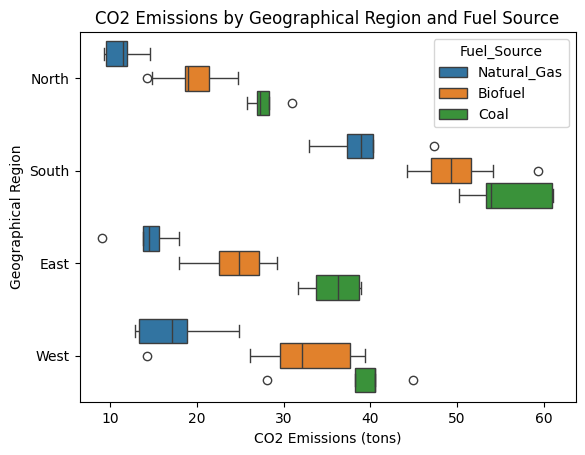

In [3]:
# 2. Create a boxplot

sns.boxplot(data=data, y=energy_design_b["Geographical_Region"], x=energy_design_b["CO2_Emissions"], hue=energy_design_b["Fuel_Source"])

plt.title('CO2 Emissions by Geographical Region and Fuel Source')
plt.xlabel('CO2 Emissions (tons)')
plt.ylabel('Geographical Region')
plt.show()

highest_co2_region = 'South'
highest_co2_source = 'Coal'

In [4]:
# 3. Apply a statistical test & check if there's a significant difference in emissions


test_results = energy_design_b.groupby('Geographical_Region').apply(
    lambda x: f_oneway(
        x[x['Fuel_Source']=='Biofuel']['CO2_Emissions'],
        x[x['Fuel_Source']=='Coal']['CO2_Emissions'], 
        x[x['Fuel_Source']=='Natural_Gas']['CO2_Emissions']
    )
)

print(test_results)




Geographical_Region
East      (50.49757647921157, 7.046450528767617e-08)
North    (45.72231764535624, 1.4439335761932012e-07)
South    (15.290983394775349, 0.0001586921779785774)
West      (12.94971744211783, 0.0003828048893388564)
dtype: object


C:\Users\chanc\AppData\Local\Temp\ipykernel_4212\4002134773.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_results = energy_design_b.groupby('Geographical_Region').apply(


In [5]:
# 4. Perform correction to determine differences

if any(result.pvalue < 0.05 for result in test_results):
    bonferroni_p_values = []
    # regions = energy_design_b["Geographical_Region"].dropna().unique().tolist()

    # for zone in regions:
    for zone in ['North', 'South', 'East', 'West']:
        fuels = ['Natural_Gas', 'Biofuel', 'Coal']
        comparisons = [(fuels[i], fuels[j]) for i in range(len(fuels)) for j in 
        range(i+1, len(fuels))]

        for fuel1, fuel2 in comparisons: 
            group1 = energy_design_b[(energy_design_b['Geographical_Region']==zone) & (energy_design_b['Fuel_Source']==fuel1)]['CO2_Emissions']
            group2 = energy_design_b[(energy_design_b['Geographical_Region']==zone) & (energy_design_b['Fuel_Source']==fuel2)]['CO2_Emissions']
            _, p_val = ttest_ind(group1, group2)
            bonferroni_p_values.append(p_val)

        diff_results = multipletests(bonferroni_p_values, alpha = 0.05, method='bonferroni')

print(diff_results[1])



[2.97842303e-03 1.60405848e-05 1.51381089e-03 1.95958890e-02
 1.04206412e-02 3.71506293e-01 1.17998627e-03 6.31245443e-05
 6.41264547e-04 2.69611996e-02 4.30884019e-03 1.00000000e+00]


## Hints

### Identify the experimental design type and create a boxplot 
* Use the `.head()` method on both DataFrames to look for column names that most closely match the experiment setup.
* Use `sns.boxplot()` to create the boxplot.
* Ensure you've set the hue argument of `sns.boxplot()` as Fuel_Source.

### Choose & apply a statistical test
* An appropriate test would be one that determines statistically significant differences between the group means.
* The response of the test should be numeric and the explanatory/independent variables have more than two combinations.
* Use `f_oneway()` (statistical function in scipy - one way ANOVA test that determines variance of two samples) to conduct the statistical test.
* Group the data by Geographical_Region with .`groupby()`.
* Use a lambda function to apply the ANOVA test (f_oneway) within each block, specifying the lambda function's argument (lambda x: apply function in regards to x).
* For each treatment group within the blocks, filter based on the 'Fuel_Source' column values and select the 'CO2_Emissions' column.
* The result will be a pandas Series where each element is a tuple (or named tuple) containing the F-statistic and p-value.

### If significant results are found, apply a correction to determine pairwise significant differences. Store the result as a tuple returned by the multipletests function.
* Use list comprehensions to create combinations of fuel types for pairwise comparisons.
* Use boolean indexing to select data for each fuel type within each geographical zone.
* Use `ttest_ind` to perform pairwise comparisons.
* Append the p-values from each t-test to a list for subsequent corrections.
* Use `multipletests` from statsmodels.sandbox.stats.multicomp to apply the Bonferroni correction, setting alpha to 0.05 and method to 'bonferroni'.